In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib
from features_flattener import split_sessions, flatten_features, get_top_digraphs,clean_feature_names

In [24]:
user_files = {
    "advait": "data/advait_keystrokes.csv",
    "chetan": "data/chetan_keystrokes.csv",
    "gayaa": "data/gayatri_keystrokes.csv",
    "purva": "data/purva_keystrokes.csv",
    "siddhant": "data/siddhant_keystrokes.csv",
}

In [25]:
top_digraphs = get_top_digraphs(user_files.values(), N=20)
top_digraphs

[('e', 'Key.space'),
 ('t', 'Key.space'),
 ('n', 'Key.space'),
 ('Key.space', 'w'),
 ('Key.space', 's'),
 ('Key.space', 't'),
 ('e', 'r'),
 ('t', 'h'),
 ('d', 'Key.space'),
 ('Key.space', 'a'),
 ('a', 'n'),
 ('r', 'Key.space'),
 ('Key.space', 'o'),
 ('h', 'e'),
 ('i', 'n'),
 ('Key.backspace', 'Key.backspace'),
 ('Key.space', 'h'),
 ('o', 'u'),
 ('y', 'Key.space'),
 ('Key.space', 'm')]

In [26]:
rows = []
for user, file in user_files.items():
    sessions = split_sessions(file, session_size=100)
    for sess in sessions:
        row = flatten_features(sess, user, top_digraphs)
        rows.append(row)

In [27]:
df = pd.DataFrame(rows).fillna(0)
df.to_csv("data/processed_data.csv")


In [28]:
print("dd_entropy" in df.columns)
print(f"shape: {df.shape}")

True
shape: (1059, 85)


In [29]:
# Correlation matrix
corr_matrix = df.drop("label", axis=1).corr()

print(corr_matrix.shape)
corr_matrix.head()

(84, 84)


,hold_r,hold_Key.space,hold_l,hold_i,hold_k,hold_e,hold_g,hold_t,hold_h,hold_c,...,hold_z,hold_:,hold_(,hold_Key.shift_r,hold_Key.print_screen,hold_Key.delete,hold_Key.caps_lock,hold_Key.media_volume_down,hold_-,hold_0
hold_r,1.000000,0.306199,0.233637,0.278610,0.051630,0.565939,0.220127,0.459648,0.238275,0.248880,...,0.035355,0.023762,0.023762,0.023762,-0.012141,-0.011932,0.004213,-0.003641,0.014136,0.022557
hold_Key.space,0.306199,1.000000,0.182634,0.201775,0.073650,0.462947,0.183083,0.372363,0.199918,0.207365,...,0.017727,0.044320,0.044320,0.044320,-0.005035,-0.004778,-0.028263,0.017637,0.019589,0.004730
hold_l,0.233637,0.182634,1.000000,0.363054,0.129669,0.400195,0.065141,0.305552,0.339166,0.242211,...,0.009559,0.040734,0.040734,0.040734,0.094890,0.095089,-0.004246,-0.004212,-0.036640,0.001493
hold_i,0.278610,0.201775,0.363054,1.000000,0.152547,0.463656,0.237731,0.347205,0.339219,0.180222,...,0.019167,0.041064,0.041064,0.041064,0.019922,0.020109,0.010465,-0.051782,-0.050650,-0.001613
hold_k,0.051630,0.073650,0.129669,0.152547,1.000000,0.113558,-0.064255,0.113154,0.096390,0.038116,...,0.042208,-0.021667,-0.021667,-0.021667,-0.021744,-0.021667,-0.014084,0.020002,0.029042,0.038158


In [30]:
threshold = 0.8

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) > threshold:
            feature1 = corr_matrix.columns[i]
            feature2 = corr_matrix.columns[j]
            
            high_corr_pairs.append((feature1, feature2, corr_value))

for f1, f2, c in high_corr_pairs[:20]:
    print(f"{f1}  ->  {f2} : {c:.2f}")

dd_std  ->  dd_max : 0.97
hold_Key.esc  ->  hold_Key.tab : 0.82
hold_Key.ctrl_l  ->  hold_ : 0.81
hold_Key.right  ->  hold_Key.shift : 0.96
hold_Key.down  ->  hold_Key.up : 0.97
hold_:  ->  hold_( : 1.00
hold_:  ->  hold_Key.shift_r : 1.00
hold_(  ->  hold_Key.shift_r : 1.00
hold_Key.print_screen  ->  hold_Key.delete : 1.00


d:\AIDS Sem 5\ML\CP\Keystroke-Rhythm-Based-User-Verifier\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20 () missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\AIDS Sem 5\ML\CP\Keystroke-Rhythm-Based-User-Verifier\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


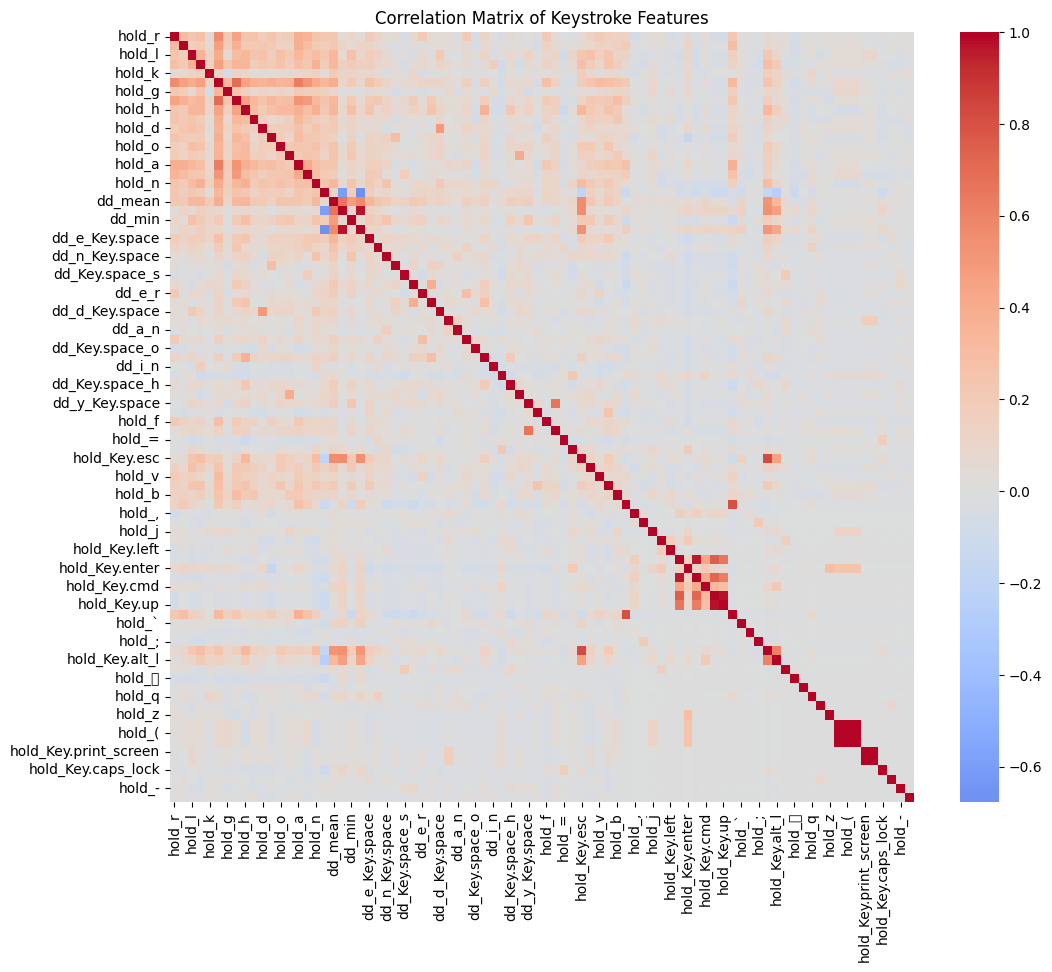

In [31]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Keystroke Features")
plt.show()

In [32]:
def custom_pca_fit(X):

    X = np.array(X)

    mean_vec = np.mean(X, axis=0)
    X_centered = X - mean_vec

    cov_matrix = np.cov(X_centered, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    sorted_idx = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[sorted_idx]
    eigenvectors = eigenvectors[:, sorted_idx]

    return mean_vec, eigenvectors, eigenvalues


def custom_pca_transform(X, mean_vec, eigenvectors, n_components):

    X = np.array(X)

    X_centered = X - mean_vec

    components = eigenvectors[:, :n_components]

    X_reduced = np.dot(X_centered, components)

    return X_reduced

In [33]:
X = clean_feature_names(df.drop("label", axis=1)).astype(np.float32)
y = df["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.18,
    random_state=42,
    stratify=y_encoded
)

In [34]:
mean_vec, eigenvectors, eigenvalues = custom_pca_fit(X_train)

X_train_pca = custom_pca_transform(X_train, mean_vec, eigenvectors, 25)
X_test_pca = custom_pca_transform(X_test, mean_vec, eigenvectors, 25)

X_train_pca.shape

(868, 25)

In [41]:
model = XGBClassifier(
    eval_metric='mlogloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

model.fit(X_train.values, y_train)

y_pred = model.predict(X_test.values)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9476439790575916


In [36]:
total_variance = np.sum(eigenvalues)

explained_variance = eigenvalues / total_variance

print("Explained variance first 10 PCs:")
print(explained_variance[:10])

Explained variance first 10 PCs:
[0.41608353 0.09757366 0.05105094 0.04530621 0.04010503 0.03917377
 0.03419625 0.03278933 0.02986035 0.02524018]


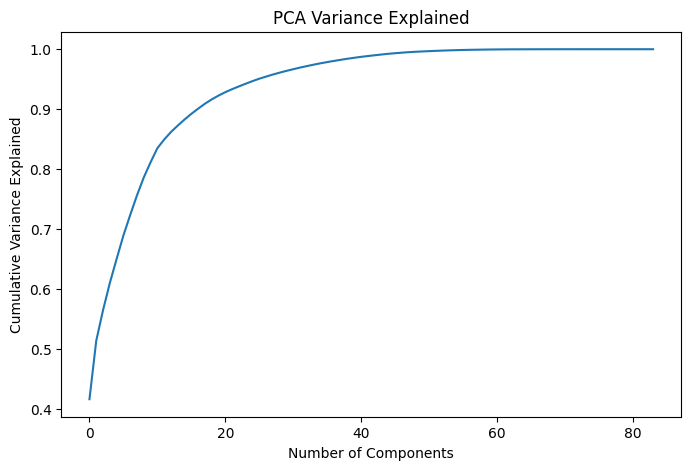

In [37]:

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Variance Explained")
plt.show()

In [38]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance.head(20))

hold_                            0.136211
hold_Key_ctrl_l                   0.080563
hold_t                            0.072800
hold_Key_enter                    0.060196
dd_Key_backspace_Key_backspace    0.050356
dd_mean                           0.043542
hold_p                            0.034822
hold_o                            0.033262
hold_Key_backspace                0.032593
hold_n                            0.031443
hold_Key_space                    0.026377
hold_e                            0.024226
hold_=                            0.022524
hold_Key_esc                      0.022444
hold_b                            0.022258
hold_h                            0.021105
hold_Key_alt_l                    0.020675
hold_g                            0.014341
dd_e_r                            0.014190
hold_u                            0.013289
dtype: float32


d:\AIDS Sem 5\ML\CP\Keystroke-Rhythm-Based-User-Verifier\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 18 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


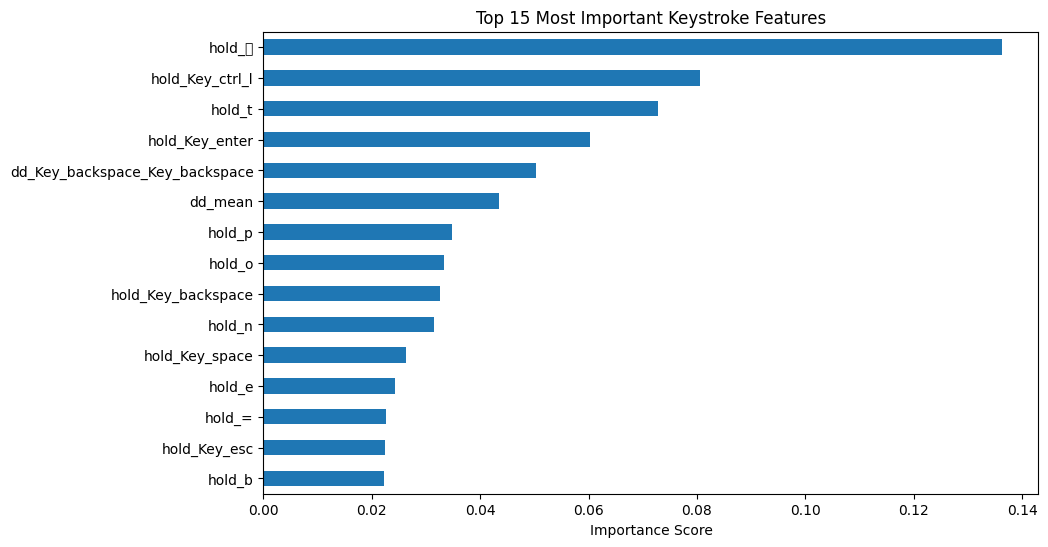

In [39]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))
top_features.plot(kind="barh")
plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Keystroke Features")
plt.xlabel("Importance Score")

plt.show()

In [40]:

joblib.dump(mean_vec, "models/pca_mean.pkl")
joblib.dump(eigenvectors, "models/pca_vectors.pkl")
joblib.dump(model, "models/xgb_keystroke_model.pkl")
joblib.dump(le, "models/label_encoder.pkl")
joblib.dump(top_digraphs, "models/top_digraphs.pkl")
feature_names = list(X.columns)
joblib.dump(feature_names, "models/feature_names.pkl")



['models/feature_names.pkl']